# Best Model Performance Test

This notebook evaluates the current saved best model against `data/final_test_dataset.csv` using the same preprocessing and feature-building flow used by the app.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

for candidate in [Path.cwd(), Path.cwd() / "src", Path.cwd().parent / "src"]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from toxic_pipeline import (
    build_all_engineered_features,
    clean_text,
    load_best_artifacts,
    protect_non_toxic_negations,
    should_override_short_neutral_input,
)


In [2]:
def resolve_test_dataset_path() -> Path:
    candidates = [
        Path.cwd() / "data" / "final_test_dataset.csv",
        Path.cwd().parent / "data" / "final_test_dataset.csv",
        Path.cwd() / "final_test_dataset.csv",
        Path.cwd() / "ignore" / "final_test_dataset.csv",
        Path.cwd().parent / "ignore" / "final_test_dataset.csv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find final_test_dataset.csv in the expected locations.")


test_dataset_path = resolve_test_dataset_path()
test_df = pd.read_csv(test_dataset_path)

if "raw_text" not in test_df.columns:
    if "comment_text" in test_df.columns:
        test_df = test_df.rename(columns={"comment_text": "raw_text"})
    else:
        raise KeyError("The test dataset must contain either `raw_text` or `comment_text`.")

if "toxic" not in test_df.columns:
    raise KeyError("The test dataset must contain a `toxic` column.")

test_df["raw_text"] = test_df["raw_text"].fillna("").astype(str)
test_df["toxic"] = test_df["toxic"].astype(int)

artifacts = load_best_artifacts()
metadata = artifacts.get("metadata", {})

print("Test dataset:", test_dataset_path)
print("Dataset shape:", test_df.shape)
print("Model artifact:", artifacts["paths"]["model"])
print("Selected features:", artifacts["feature_columns"])
print("Training metadata F1:", metadata.get("test_f1"))
print("Training metadata ROC-AUC:", metadata.get("test_roc_auc"))

test_df.head()


Test dataset: D:\Code\Repos\CPE232\project\data\final_test_dataset.csv
Dataset shape: (63117, 3)
Model artifact: D:\Code\Repos\CPE232\project\src\best_model_final.pkl
Selected features: ['Character Count', 'Profanity Count', 'Repeated Character Pattern Count', 'Identity-group Term Count', 'URL Count', 'Negation Count', 'Non-toxic Negation Pattern Count']
Training metadata F1: 0.7584118438761777
Training metadata ROC-AUC: 0.9626497598085998


,raw_text,clean_text,toxic
0,Thank you for understanding. I think very high...,thank you for understanding i think very highl...,0
1,:Dear god this site is horrible.,dear god this site is horrible,0
2,"""::: Somebody will invariably try to add Relig...",somebody will invariably try to add religion r...,0
3,""" \n\n It says it right there that it IS a typ...",it says it right there that it is a type the t...,0
4,""" \n\n == Before adding a new product to the l...",before adding a new product to the list make s...,0


## Build Test Features

This uses the same protected text, cleaned text, engineered features, and vectorizers as the current best model pipeline.


In [3]:
raw_texts = test_df["raw_text"]
protected_texts = raw_texts.apply(protect_non_toxic_negations)
clean_texts = protected_texts.apply(clean_text)

engineered_rows = [build_all_engineered_features(text).iloc[0].to_dict() for text in raw_texts]
engineered_frame = pd.DataFrame(engineered_rows)[artifacts["feature_columns"]]

x_word = artifacts["word_vectorizer"].transform(clean_texts)
x_eng = csr_matrix(artifacts["scaler"].transform(engineered_frame.values))
x_test = hstack([x_word, x_eng], format="csr")
y_test = test_df["toxic"].to_numpy()

print("Feature matrix shape:", x_test.shape)
print("Positive label rate:", round(float(y_test.mean()), 4))


Feature matrix shape: (63117, 10007)
Positive label rate: 0.0962


## Evaluate Current Best Model

The predictions below also apply the same short-neutral override used in the app so this notebook reflects the current runtime behavior.


In [4]:
model = artifacts["model"]
y_pred = model.predict(x_test).astype(int)
y_prob = model.predict_proba(x_test)[:, 1].astype(float)

override_mask = raw_texts.apply(should_override_short_neutral_input).to_numpy(dtype=bool)
y_pred[override_mask] = 0
y_prob[override_mask] = 0.15

metrics_df = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "short_neutral_overrides": int(override_mask.sum()),
        }
    ]
)

display(metrics_df.round(4))
print(classification_report(y_test, y_pred, target_names=["Not Toxic", "Toxic"], zero_division=0))


,accuracy,precision,recall,f1,roc_auc,short_neutral_overrides
0,0.906,0.5068,0.8386,0.6318,0.9515,14


              precision    recall  f1-score   support

   Not Toxic       0.98      0.91      0.95     57045
       Toxic       0.51      0.84      0.63      6072

    accuracy                           0.91     63117
   macro avg       0.74      0.88      0.79     63117
weighted avg       0.94      0.91      0.92     63117



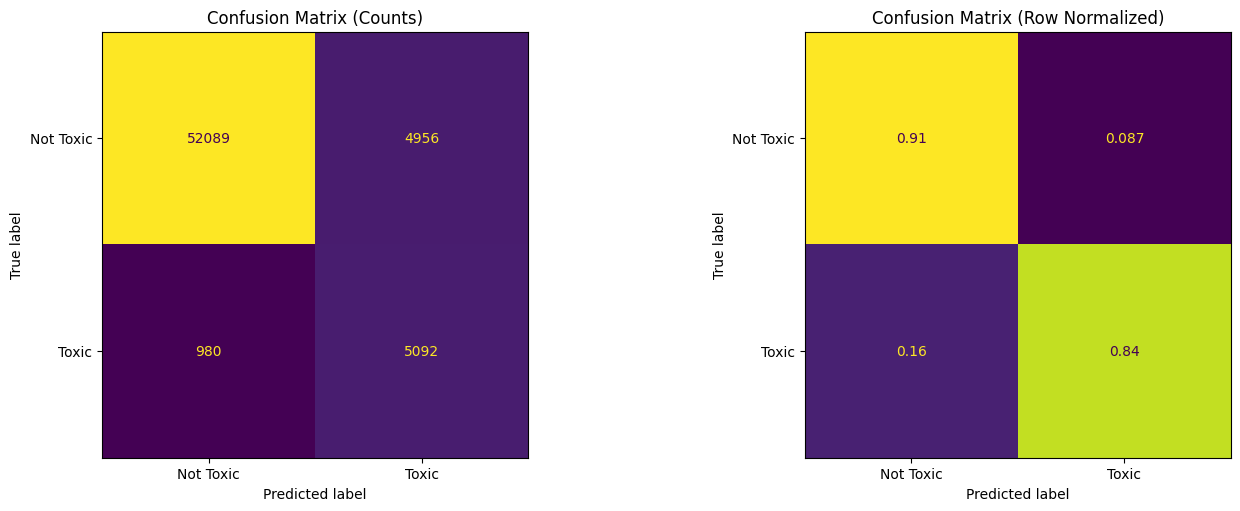

In [5]:
cm = confusion_matrix(y_test, y_pred)
cm_normalized = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

ConfusionMatrixDisplay(cm, display_labels=["Not Toxic", "Toxic"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Counts)")

ConfusionMatrixDisplay(cm_normalized, display_labels=["Not Toxic", "Toxic"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix (Row Normalized)")

plt.show()


In [6]:
results_df = test_df[["raw_text", "toxic"]].copy()
results_df["predicted_toxic"] = y_pred
results_df["toxic_probability"] = y_prob
results_df["error_type"] = np.where(
    results_df["toxic"] == results_df["predicted_toxic"],
    "Correct",
    np.where(results_df["toxic"] == 1, "False Negative", "False Positive"),
)

false_positive_examples = results_df.loc[results_df["error_type"] == "False Positive", ["raw_text", "toxic_probability"]].head(10)
false_negative_examples = results_df.loc[results_df["error_type"] == "False Negative", ["raw_text", "toxic_probability"]].head(10)

print("False positives:")
display(false_positive_examples)

print("False negatives:")
display(false_negative_examples)


False positives:


,raw_text,toxic_probability
1,:Dear god this site is horrible.,0.804816
16,""" \n\n ==balance== \n This page has one senten...",1.000000
26,I WILL BURN YOU TO HELL IF YOU REVOKE MY TALK ...,0.873752
61,"**I just revamped WP:FART, I thought a little ...",0.574832
76,""" \n\n == Shameless Canvass == \n\n Hello, Dia...",0.893711
77,WHAT THE HELL \n\n Justin,0.932381
85,"::::Buffoon Synonyms: bozo, buffo, clown, c...",0.998912
97,and lewd sex in China,0.838295
100,== Bitch Creek Cow Camp Idaho == \n\n Hey- Jus...,0.893935
118,Um that is your opinion i belive DBZ tenchaich...,0.907881


False negatives:


,raw_text,toxic_probability
37,How dare you vandalize that page about the HMS...,0.428149
87,":Eek, but shes cute in an earthy kind of way. ...",0.339671
125,:::::::::Moi? Ego? I am mortified that you cou...,0.232997
291,"GIVE BLOWJOBS TO HOT WOMEN FROM ALDERLEY EDGE,...",0.280340
431,"That's helpful. MOS be damned, Thecodingprojec...",0.350836
481,== Intolerance in India == \n\n india is a Ge...,0.371876
538,:* Because the overall aim of the project is w...,0.448696
651,""" \n\n Utterly utterly tiny insignificant anal...",0.360583
653,Y una mierda.Tu puta madre'',0.429065
728,== stop being an ass == \n\n It seems you are ...,0.324754
